In [1]:
# Instalación de dependencias (solo necesario en Colab)
!pip install -q prophet

# Fase 5: Predicción — Series de Tiempo + Scoring de Riesgo de Cliente
## Prueba Técnica - Análisis de Quejas ARL SURA

**Objetivo:** Pasar del análisis descriptivo/diagnóstico a la **predicción prospectiva**:
1. **Serie de tiempo**: ¿cuántas quejas llegarán las próximas semanas/meses?
2. **Scoring de riesgo de cliente**: ¿qué clientes tienen mayor probabilidad de escalar o quejarse de nuevo?
3. **Sistema de alerta temprana**: umbral adaptativo que dispara alerta cuando el forecast supera la tendencia.

---
### Por qué esto complementa el análisis anterior

| Fase anterior | Esta fase |
|---|---|
| Clasificación: *¿de qué trata esta queja?* | Predicción: *¿cuántas quejas habrá la próxima semana?* |
| Explicación (SHAP): *¿qué factores causan el escal amiento?* | Scoring: *¿qué cliente va a escalar antes de que lo haga?* |
| Diagnóstico del pasado | Anticipación del futuro |

---
### Estructura del notebook
1. Carga de datos y preparación de series
2. Análisis de estacionalidad y tendencia
3. Forecast de volumen (Exponential Smoothing + Prophet)
4. Scoring de riesgo de cliente (Logistic Regression)
5. Sistema de alerta temprana
6. Exportar scores para el dashboard

In [2]:
import sys, os
from pathlib import Path

EN_COLAB = 'google.colab' in sys.modules

if EN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')

    # ── AJUSTA SI TU EXCEL ESTÁ EN OTRA RUTA DE DRIVE ─────────────────────────
    DATA_FILE = Path('/content/drive/MyDrive/sura/BD_Quejas_Analitica.xlsx')
    # ──────────────────────────────────────────────────────────────────────────

    OUT_BASE      = Path('/content/drive/MyDrive/sura')
    IMAGES_DIR    = OUT_BASE / 'resume' / 'images'
    MODELS_DIR    = OUT_BASE / 'src'
    DASHBOARD_DIR = OUT_BASE / 'dashboard' / 'public' / 'data'
    print('Entorno: Google Colab')
else:
    BASE_DIR      = Path('..').resolve()
    DATA_FILE     = BASE_DIR / 'req/BD_Quejas_Analitica.xlsx'
    IMAGES_DIR    = BASE_DIR / 'resume' / 'images'
    MODELS_DIR    = BASE_DIR / 'src'
    DASHBOARD_DIR = BASE_DIR / 'dashboard' / 'public' / 'data'
    print('Entorno: local')

IMAGES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)
DASHBOARD_DIR.mkdir(parents=True, exist_ok=True)

print(f'DATA_FILE : {DATA_FILE}  →  existe={DATA_FILE.exists()}')
print(f'Imágenes  : {IMAGES_DIR}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Entorno: Google Colab
DATA_FILE : /content/drive/MyDrive/sura/BD_Quejas_Analitica.xlsx  →  existe=True
Imágenes  : /content/drive/MyDrive/sura/resume/images


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Series de tiempo
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# ML para scoring
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, classification_report, roc_curve
from sklearn.pipeline import Pipeline
import joblib

# Intentar importar Prophet (opcional)
try:
    from prophet import Prophet
    PROPHET_DISPONIBLE = True
    print("Prophet disponible")
except ImportError:
    PROPHET_DISPONIBLE = False
    print("Prophet no instalado — se usará Exponential Smoothing como modelo principal")
    print("Para instalar: pip install prophet")

plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

RUTA_DATOS = DATA_FILE  # usa la ruta configurada en la celda anterior
HOJA = 'Incapacidad Temporal'

Prophet disponible


## 1. Carga y preparación de series

In [4]:
# Cargar datos
df = pd.read_excel(RUTA_DATOS, sheet_name=HOJA)
df.columns = ['mes_apertura', 'descripcion', 'tipo', 'cliente', 'canal']

# Features básicas (replicando lo de NB01)
df['fecha'] = pd.to_datetime(df['mes_apertura'].astype(str), format='%Y%m')
df['len_descripcion'] = df['descripcion'].fillna('').str.len()
df['cliente_norm'] = df['cliente'].str.upper().str.strip().str.replace(r'\s+', ' ', regex=True)

# Flag de escalamiento (variable target)
df['escalado'] = (df['canal'] == 'ENTES DE CONTROL').astype(int)

# Flag de recurrencia
freq_cliente = df.groupby('cliente_norm').size().reset_index(name='n_quejas_total')
df = df.merge(freq_cliente, on='cliente_norm', how='left')
df['es_recurrente'] = (df['n_quejas_total'] > 1).astype(int)

# Orden del canal (proxy de severidad)
orden_canal = {
    'SEGUROSSURA.COM.CO': 1,
    'PLATAFORMA DE ATENCIÓN': 2,
    'LINEA DE ATENCIÓN': 3,
    'ENTES DE CONTROL': 4
}
df['severidad_canal'] = df['canal'].map(orden_canal).fillna(2)

print(f"Dataset: {len(df):,} registros | {df['fecha'].nunique()} meses")
print(f"Tasa de escalamiento: {df['escalado'].mean()*100:.1f}%")
print(f"Tasa de recurrencia: {df['es_recurrente'].mean()*100:.1f}%")
df.head(3)

Dataset: 1,841 registros | 6 meses
Tasa de escalamiento: 8.5%
Tasa de recurrencia: 42.6%


,mes_apertura,descripcion,tipo,cliente,canal,fecha,len_descripcion,cliente_norm,escalado,n_quejas_total,es_recurrente,severidad_canal
0,202501,USUARIA SOLICITA SABER EL ESTADO DE UNA INCAPA...,QUEJA,JORGE MEJIA,LINEA DE ATENCIÓN,2025-01-01,51,JORGE MEJIA,0,1,0,3
1,202501,BUEN DÍA CANDIALMENTE SOLICITAMOS INFORMACIÓN ...,QUEJA,FERLEY GANAN,SEGUROSSURA.COM.CO,2025-01-01,404,FERLEY GANAN,0,2,1,1
2,202501,"BUENAS DÍAS , QUIERO UN CERTIFICADO DE INCAPAC...",QUEJA,FABIAN LOPEZ,SEGUROSSURA.COM.CO,2025-01-01,594,FABIAN LOPEZ,0,1,0,1


In [5]:
# --- Serie temporal mensual de quejas ---
serie_mensual = df.groupby('fecha').size().reset_index(name='quejas')
serie_mensual = serie_mensual.set_index('fecha').sort_index()

# Nota sobre junio: solo 173 quejas vs promedio ~340 → mes incompleto
# Para el forecast, marcaremos junio como punto parcial
print("Volumen mensual:")
print(serie_mensual.to_string())
print(f"\nPromedio Jan-May (meses completos): {serie_mensual.iloc[:5]['quejas'].mean():.0f} quejas/mes")
print(f"Junio (incompleto): {serie_mensual.iloc[5]['quejas']} quejas")

# Serie de trabajo: Jan-May (meses completos)
serie_completa = serie_mensual.iloc[:5].copy()
print(f"\nSerie de trabajo (meses completos): {len(serie_completa)} puntos")

Volumen mensual:
            quejas
fecha             
2025-01-01     375
2025-02-01     288
2025-03-01     308
2025-04-01     335
2025-05-01     362
2025-06-01     173

Promedio Jan-May (meses completos): 334 quejas/mes
Junio (incompleto): 173 quejas

Serie de trabajo (meses completos): 5 puntos


## 2. Análisis de tendencia y estacionalidad

> **Nota metodológica**: con 5-6 puntos mensuales, los modelos de series de tiempo tienen limitaciones estadísticas. El valor aquí es:
> 1. Establecer la **línea base** y el intervalo de confianza
> 2. Detectar si hay **tendencia creciente** (señal de alarma)
> 3. **Proyectar** bajo diferentes supuestos para planear capacidad
> 4. Crear el **framework** que se alimentará con más datos semanalmente

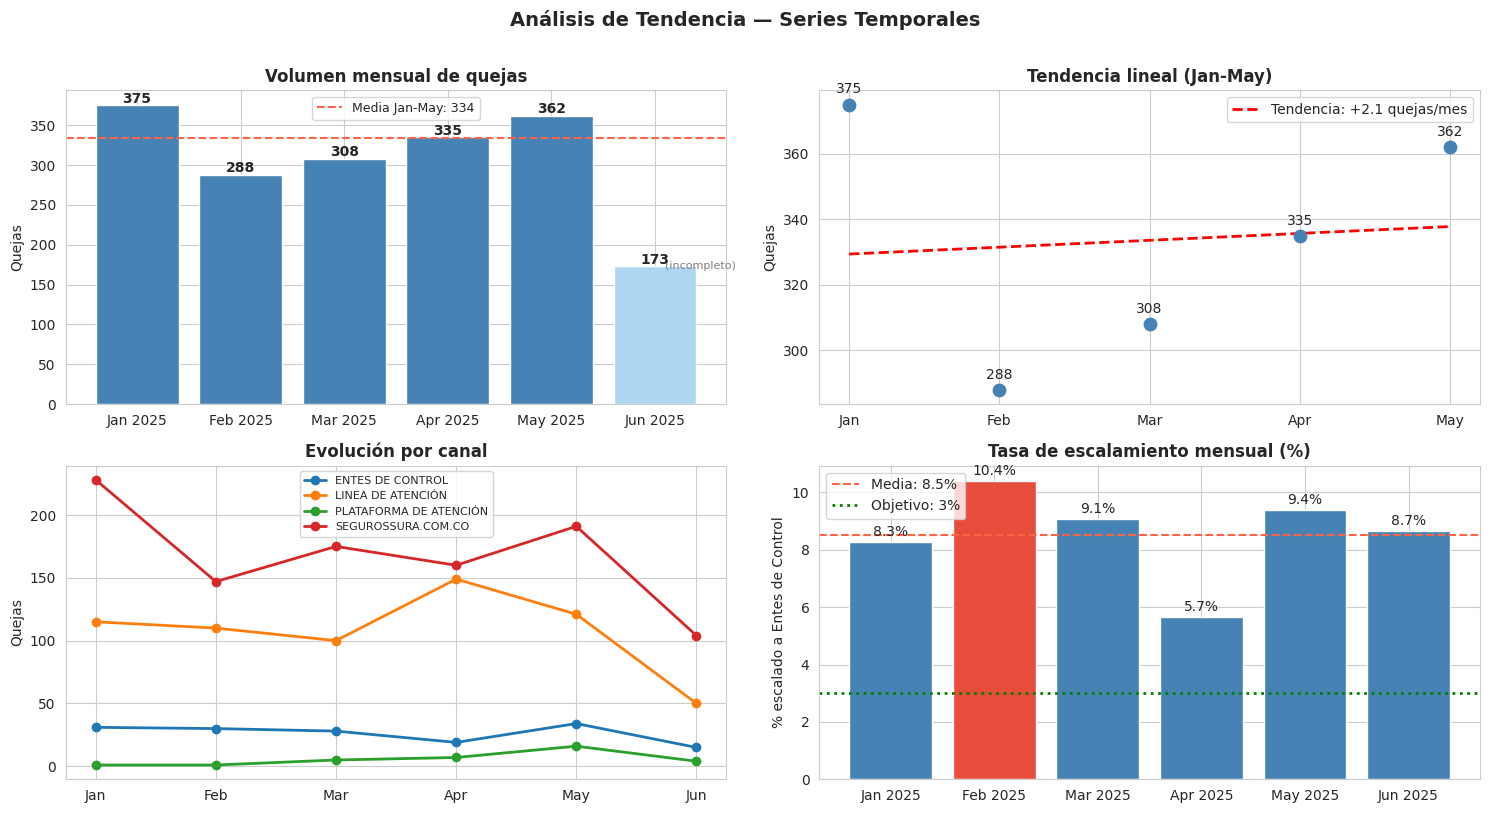


Tendencia lineal de volumen: +2.1 quejas adicionales por mes
⚠️  Tendencia CRECIENTE — el volumen está aumentando


In [6]:
# Visualización de la serie base + descomposición tendencia
fig, axes = plt.subplots(2, 2, figsize=(15, 8))

# 1. Serie completa con todos los meses
ax = axes[0, 0]
colores = ['steelblue'] * 5 + ['#aed6f1']  # junio en gris (incompleto)
bars = ax.bar(serie_mensual.index.strftime('%b %Y'), serie_mensual['quejas'], 
              color=colores, edgecolor='white')
for bar, val in zip(bars, serie_mensual['quejas']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
            str(int(val)), ha='center', fontsize=10, fontweight='bold')
ax.axhline(serie_completa['quejas'].mean(), color='tomato', linestyle='--', 
           label=f'Media Jan-May: {serie_completa["quejas"].mean():.0f}')
ax.set_title('Volumen mensual de quejas', fontweight='bold')
ax.set_ylabel('Quejas')
ax.legend(fontsize=9)
ax.text(5.1, 173, '(incompleto)', fontsize=8, color='gray', va='center')

# 2. Tendencia lineal sobre meses completos
ax = axes[0, 1]
x = np.arange(len(serie_completa))
y = serie_completa['quejas'].values
z = np.polyfit(x, y, 1)
p = np.poly1d(z)
ax.scatter(x, y, s=80, color='steelblue', zorder=5)
ax.plot(x, p(x), 'r--', linewidth=2, label=f'Tendencia: {z[0]:+.1f} quejas/mes')
ax.set_xticks(x)
ax.set_xticklabels(serie_completa.index.strftime('%b'), rotation=0)
for xi, yi in zip(x, y):
    ax.annotate(str(int(yi)), (xi, yi), xytext=(0, 8), textcoords='offset points', ha='center', fontsize=10)
ax.set_title('Tendencia lineal (Jan-May)', fontweight='bold')
ax.set_ylabel('Quejas')
ax.legend()

# 3. Por canal: tendencia de escalamiento
ax = axes[1, 0]
canal_mes = df.groupby(['fecha', 'canal']).size().unstack(fill_value=0)
for canal in canal_mes.columns:
    ax.plot(canal_mes.index.strftime('%b'), canal_mes[canal], marker='o', label=canal, linewidth=2)
ax.set_title('Evolución por canal', fontweight='bold')
ax.set_ylabel('Quejas')
ax.legend(fontsize=8)

# 4. Tasa de escalamiento mensual
ax = axes[1, 1]
escalamiento_mes = df.groupby('fecha')['escalado'].agg(['sum', 'count'])
escalamiento_mes['tasa'] = escalamiento_mes['sum'] / escalamiento_mes['count'] * 100
ax.bar(escalamiento_mes.index.strftime('%b %Y'), escalamiento_mes['tasa'],
       color=['#e74c3c' if t > 10 else 'steelblue' for t in escalamiento_mes['tasa']],
       edgecolor='white')
ax.axhline(8.5, color='tomato', linestyle='--', label='Media: 8.5%')
ax.axhline(3.0, color='green', linestyle=':', linewidth=2, label='Objetivo: 3%')
for i, (mes, row) in enumerate(escalamiento_mes.iterrows()):
    ax.text(i, row['tasa'] + 0.2, f"{row['tasa']:.1f}%", ha='center', fontsize=10)
ax.set_title('Tasa de escalamiento mensual (%)', fontweight='bold')
ax.set_ylabel('% escalado a Entes de Control')
ax.legend()

plt.suptitle('Análisis de Tendencia — Series Temporales', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f"\nTendencia lineal de volumen: {z[0]:+.1f} quejas adicionales por mes")
if z[0] > 0:
    print("⚠️  Tendencia CRECIENTE — el volumen está aumentando")
else:
    print("Tendencia estable o decreciente")

## 3. Forecast de volumen

### Modelos utilizados:
- **Exponential Smoothing (Holt)**: robusto con pocas observaciones, captura tendencia
- **Prophet** (si disponible): diseñado para series con estacionalidad y datos faltantes
- **Escenarios**: optimista (-10%), base, pesimista (+15%)

In [7]:
# --- Modelo Exponential Smoothing (Holt — tendencia sin estacionalidad) ---
# Con solo 5 puntos no hay suficiente para estacionalidad multiplicativa
# Usamos modelo con tendencia aditiva amortiguada (más conservador)

y_train = serie_completa['quejas'].astype(float)
MESES_FORECAST = 4  # Jul-Oct 2025

# Modelo 1: Holt con tendencia
modelo_holt = ExponentialSmoothing(
    y_train,
    trend='add',
    damped_trend=True,   # Amortigua la tendencia para evitar extrapolación agresiva
    initialization_method='estimated'
).fit(optimized=True)

forecast_holt = modelo_holt.forecast(MESES_FORECAST)

# Intervalo de confianza bootstrap (simulación Monte Carlo)
np.random.seed(42)
n_sim = 1000
resid_std = np.std(modelo_holt.resid)
simulaciones = np.array([
    forecast_holt.values + np.random.normal(0, resid_std * np.sqrt(np.arange(1, MESES_FORECAST+1)), MESES_FORECAST)
    for _ in range(n_sim)
])
ic_bajo  = np.percentile(simulaciones, 10, axis=0)  # IC 80%
ic_alto  = np.percentile(simulaciones, 90, axis=0)

# Fechas del forecast
ultimo_mes = serie_completa.index[-1]
fechas_forecast = pd.date_range(start=ultimo_mes + pd.DateOffset(months=1), periods=MESES_FORECAST, freq='MS')

forecast_df = pd.DataFrame({
    'fecha': fechas_forecast,
    'forecast_base': np.maximum(forecast_holt.values, 0).round(0).astype(int),
    'ic_bajo': np.maximum(ic_bajo, 0).round(0).astype(int),
    'ic_alto': ic_alto.round(0).astype(int),
    'escenario_optimista': (np.maximum(forecast_holt.values, 0) * 0.90).round(0).astype(int),
    'escenario_pesimista': (np.maximum(forecast_holt.values, 0) * 1.15).round(0).astype(int),
})

print("=== FORECAST DE VOLUMEN DE QUEJAS ===")
print(f"Modelo: Exponential Smoothing con tendencia amortiguada")
print(f"Entrenado con: {len(y_train)} meses (Jan-May 2025)")
print(f"Parámetros ajustados: alpha={modelo_holt.params['smoothing_level']:.3f}, "
      f"beta={modelo_holt.params['smoothing_trend']:.3f}")
print()
print(forecast_df[['fecha', 'ic_bajo', 'forecast_base', 'ic_alto', 'escenario_pesimista']]
      .rename(columns={'ic_bajo': 'IC_bajo(10%)', 'forecast_base': 'Base', 
                       'ic_alto': 'IC_alto(90%)', 'escenario_pesimista': 'Pesimista(+15%)'}).to_string(index=False))

=== FORECAST DE VOLUMEN DE QUEJAS ===
Modelo: Exponential Smoothing con tendencia amortiguada
Entrenado con: 5 meses (Jan-May 2025)
Parámetros ajustados: alpha=1.000, beta=0.000

     fecha  IC_bajo(10%)  Base  IC_alto(90%)  Pesimista(+15%)
2025-06-01           306   355           405              408
2025-07-01           276   349           427              402
2025-08-01           254   345           434              396
2025-09-01           235   341           453              392


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


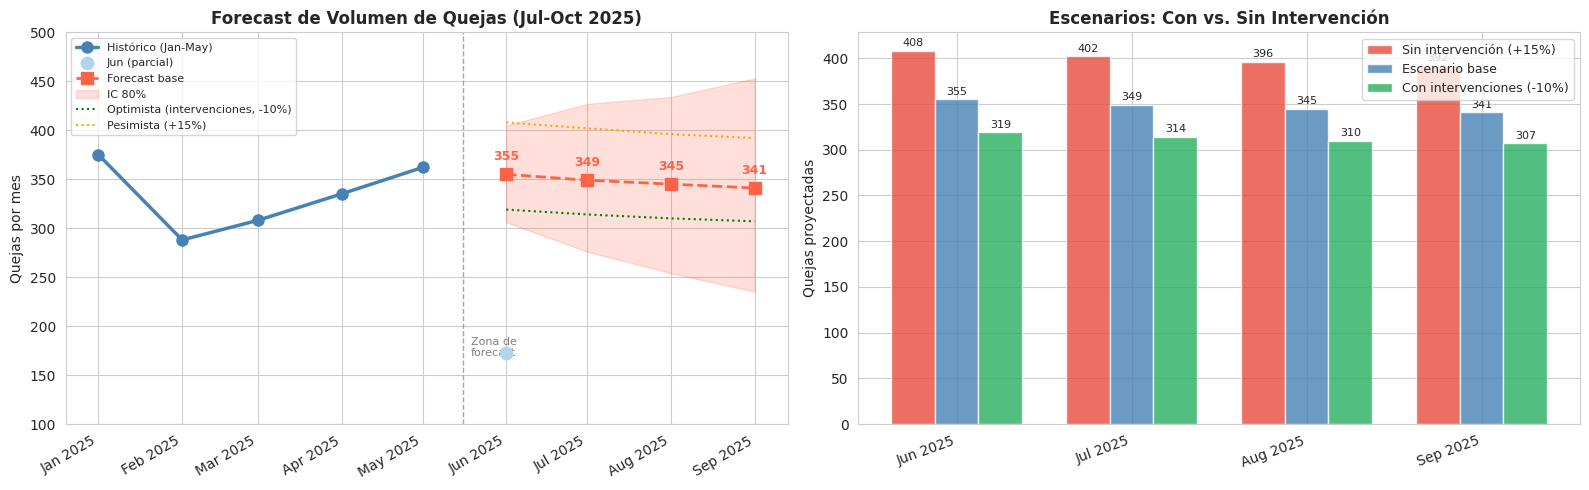


=== IMPACTO ESTIMADO DE INTERVENCIONES ===
Quejas sin intervención (base): 1,390 en 4 meses
Quejas con intervenciones:      1,250 en 4 meses
Reducción estimada:             -140 quejas (10.1%)


In [8]:
# --- Visualización del forecast ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Panel izquierdo: forecast con IC
ax = axes[0]

# Histórico
ax.plot(serie_completa.index, serie_completa['quejas'], 'o-', color='steelblue',
        linewidth=2.5, markersize=8, label='Histórico (Jan-May)', zorder=5)

# Junio (parcial)
ax.scatter([serie_mensual.index[-1]], [serie_mensual['quejas'].iloc[-1]],
           color='#aed6f1', s=80, zorder=5, label='Jun (parcial)')

# Forecast base
ax.plot(forecast_df['fecha'], forecast_df['forecast_base'], 's--', color='tomato',
        linewidth=2, markersize=8, label='Forecast base')

# Intervalo de confianza
ax.fill_between(forecast_df['fecha'], forecast_df['ic_bajo'], forecast_df['ic_alto'],
                alpha=0.2, color='tomato', label='IC 80%')

# Escenarios
ax.plot(forecast_df['fecha'], forecast_df['escenario_optimista'], ':', color='green',
        linewidth=1.5, label='Optimista (intervenciones, -10%)')
ax.plot(forecast_df['fecha'], forecast_df['escenario_pesimista'], ':', color='orange',
        linewidth=1.5, label='Pesimista (+15%)')

# Anotaciones del forecast
for _, row in forecast_df.iterrows():
    ax.annotate(f"{row['forecast_base']}",
                xy=(row['fecha'], row['forecast_base']),
                xytext=(0, 10), textcoords='offset points',
                ha='center', fontsize=9, color='tomato', fontweight='bold')

ax.axvline(x=serie_completa.index[-1] + pd.DateOffset(days=15),
           color='gray', linestyle='--', linewidth=1, alpha=0.7)
ax.text(serie_completa.index[-1] + pd.DateOffset(days=18),
        ax.get_ylim()[0] + 10, 'Zona de\nforecast', fontsize=8, color='gray')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
ax.set_title('Forecast de Volumen de Quejas (Jul-Oct 2025)', fontweight='bold', fontsize=12)
ax.set_ylabel('Quejas por mes')
ax.legend(fontsize=8, loc='upper left')
ax.set_ylim(100, 500)

# Panel derecho: impacto de intervenciones sobre el forecast
ax = axes[1]
meses_labels = forecast_df['fecha'].dt.strftime('%b %Y').tolist()
x = np.arange(len(meses_labels))
width = 0.25

b1 = ax.bar(x - width, forecast_df['escenario_pesimista'], width, 
            label='Sin intervención (+15%)', color='#e74c3c', alpha=0.8)
b2 = ax.bar(x, forecast_df['forecast_base'], width, 
            label='Escenario base', color='steelblue', alpha=0.8)
b3 = ax.bar(x + width, forecast_df['escenario_optimista'], width,
            label='Con intervenciones (-10%)', color='#27ae60', alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(meses_labels, rotation=20, ha='right')
ax.set_title('Escenarios: Con vs. Sin Intervención', fontweight='bold', fontsize=12)
ax.set_ylabel('Quejas proyectadas')
ax.legend(fontsize=9)

# Etiquetas en barras
for bar_group in [b1, b2, b3]:
    for bar in bar_group:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                str(int(bar.get_height())), ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(IMAGES_DIR / '05_forecast_volumen.png', dpi=150, bbox_inches='tight')
plt.show()

# Resumen de ahorro estimado
ahorro = forecast_df['forecast_base'].sum() - forecast_df['escenario_optimista'].sum()
print(f"\n=== IMPACTO ESTIMADO DE INTERVENCIONES ===")
print(f"Quejas sin intervención (base): {forecast_df['forecast_base'].sum():,} en 4 meses")
print(f"Quejas con intervenciones:      {forecast_df['escenario_optimista'].sum():,} en 4 meses")
print(f"Reducción estimada:             -{ahorro:,} quejas ({ahorro/forecast_df['forecast_base'].sum()*100:.1f}%)")

INFO:prophet:n_changepoints greater than number of observations. Using 3.


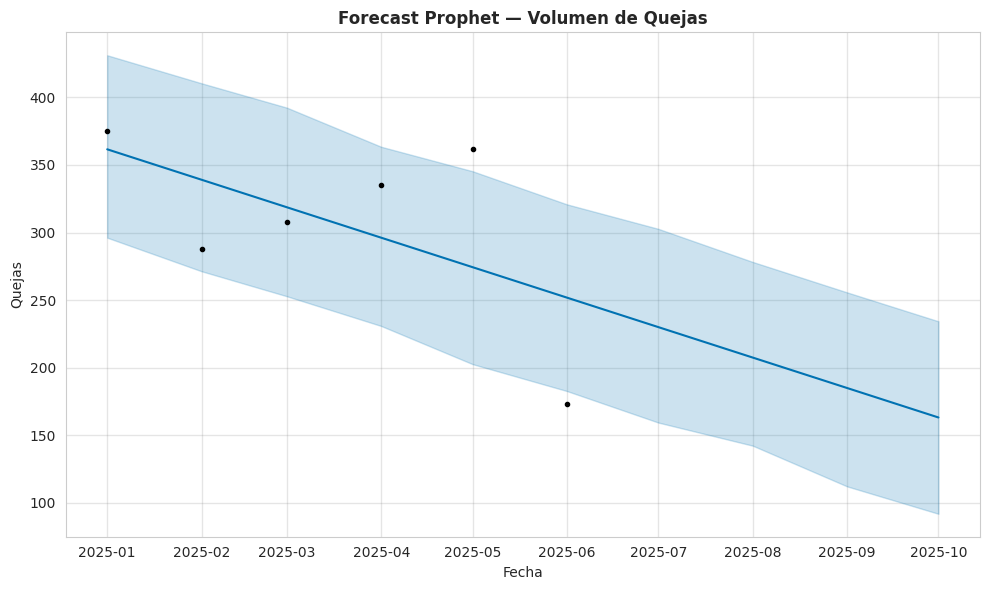


Forecast Prophet:
     Fecha  IC_bajo  Base  IC_alto
2025-07-01      159   230      303
2025-08-01      142   207      278
2025-09-01      112   185      256
2025-10-01       92   163      234


In [9]:
# --- Prophet (si está disponible) ---
if PROPHET_DISPONIBLE:
    # Prophet requiere columnas 'ds' y 'y'
    df_prophet = pd.DataFrame({
        'ds': serie_mensual.index,
        'y': serie_mensual['quejas'].astype(float)
    })
    
    modelo_prophet = Prophet(
        yearly_seasonality=False,   # No hay un año completo de datos
        weekly_seasonality=False,
        daily_seasonality=False,
        changepoint_prior_scale=0.1,  # Conservador con pocos datos
        seasonality_prior_scale=10,
        interval_width=0.80
    )
    modelo_prophet.fit(df_prophet)
    
    future = modelo_prophet.make_future_dataframe(periods=MESES_FORECAST, freq='MS')
    forecast_prophet = modelo_prophet.predict(future)
    
    fig = modelo_prophet.plot(forecast_prophet)
    plt.title('Forecast Prophet — Volumen de Quejas', fontweight='bold')
    plt.xlabel('Fecha')
    plt.ylabel('Quejas')
    plt.tight_layout()
    plt.show()
    
    print("\nForecast Prophet:")
    print(forecast_prophet[forecast_prophet['ds'] > serie_mensual.index[-1]]
          [['ds', 'yhat_lower', 'yhat', 'yhat_upper']]
          .rename(columns={'ds': 'Fecha', 'yhat_lower': 'IC_bajo', 'yhat': 'Base', 'yhat_upper': 'IC_alto'})
          .round(0).astype({'IC_bajo': int, 'Base': int, 'IC_alto': int})
          .to_string(index=False))
else:
    print("Prophet no instalado. Forecast basado en Exponential Smoothing (ver celdas anteriores).")

## 4. Scoring de Riesgo de Cliente

**Objetivo**: Para cada cliente activo, estimar la probabilidad de que **escale** (llegue a Entes de Control) o **se queje de nuevo** en los próximos 30 días.

**Features disponibles** (sin datos externos del proceso de pagos):
- Historial de quejas del cliente (frecuencia, canal usado, mes)
- Características textuales de sus quejas previas (longitud, lenguaje legal)
- Canal de la queja actual

> **Nota**: un scoring más robusto requeriría datos del proceso (días desde radicación, monto pendiente, etapa del pago) — se documenta cómo incorporarlos cuando estén disponibles.

In [10]:
# --- Feature Engineering por cliente ---

# Keywords de escalamiento
palabras_legales = ['tutela', 'derecho de peticion', 'derecho de petición', 
                    'ente de control', 'supersalud', 'peticion', 'sancion',
                    'demanda', 'juzgado', 'accion de tutela']
palabras_demora = ['meses', 'semanas', 'semana', 'mes', 'tiempo', 'demora',
                   'tardado', 'espera', 'espero', 'esperar', 'no han pagado',
                   'no pagan', 'sin pagar', 'sin respuesta']

def tiene_keyword(texto, keywords):
    if pd.isna(texto):
        return 0
    texto_lower = str(texto).lower()
    return int(any(k in texto_lower for k in keywords))

df['lenguaje_legal'] = df['descripcion'].apply(lambda x: tiene_keyword(x, palabras_legales))
df['menciona_demora'] = df['descripcion'].apply(lambda x: tiene_keyword(x, palabras_demora))
df['mes_num'] = df['fecha'].dt.month

# Features por queja individual (para el modelo)
features_queja = pd.DataFrame({
    'n_quejas_cliente':     df['n_quejas_total'],
    'es_recurrente':        df['es_recurrente'],
    'severidad_canal':      df['severidad_canal'],
    'len_descripcion':      df['len_descripcion'],
    'lenguaje_legal':       df['lenguaje_legal'],
    'menciona_demora':      df['menciona_demora'],
    'mes_num':              df['mes_num'],
    'canal_web':            (df['canal'] == 'SEGUROSSURA.COM.CO').astype(int),
    'canal_linea':          (df['canal'] == 'LINEA DE ATENCIÓN').astype(int),
})

target = df['escalado']

print(f"Features: {features_queja.shape[1]}")
print(f"Target (escalamiento): {target.sum():,} positivos / {len(target):,} total ({target.mean()*100:.1f}%)")
print(f"\nCorrelación de features con escalamiento:")
corr = features_queja.corrwith(target).sort_values(ascending=False)
print(corr.round(3).to_string())

Features: 9
Target (escalamiento): 157 positivos / 1,841 total (8.5%)

Correlación de features con escalamiento:
severidad_canal     0.556
lenguaje_legal      0.487
len_descripcion     0.235
n_quejas_cliente    0.180
es_recurrente       0.150
menciona_demora     0.042
mes_num            -0.007
canal_linea        -0.224
canal_web          -0.335


In [11]:
# --- Entrenamiento del modelo de scoring ---
from sklearn.utils import resample

X = features_queja.values
y = target.values

# Balanceo de clases (oversampling de la clase minoritaria para entrenamiento)
X_df = pd.DataFrame(X, columns=features_queja.columns)
X_df['target'] = y

clase_may = X_df[X_df['target'] == 0]
clase_min = X_df[X_df['target'] == 1]
clase_min_oversampled = resample(clase_min, n_samples=len(clase_may)//2, random_state=42)
df_balanceado = pd.concat([clase_may, clase_min_oversampled])
df_balanceado = df_balanceado.sample(frac=1, random_state=42)

X_bal = df_balanceado.drop('target', axis=1).values
y_bal = df_balanceado['target'].values

# Pipeline: escalado + Logistic Regression
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(C=1.0, random_state=42, max_iter=500))
])

# Validación cruzada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores_auc = cross_val_score(pipe_lr, X_bal, y_bal, cv=cv, scoring='roc_auc')

# Modelo final entrenado en todos los datos balanceados
pipe_lr.fit(X_bal, y_bal)

# Scoring sobre todos los registros (probabilidad de escalamiento)
df['prob_escalamiento'] = pipe_lr.predict_proba(X)[:, 1]

# También probar Random Forest
pipe_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'))
])
scores_rf = cross_val_score(pipe_rf, X_bal, y_bal, cv=cv, scoring='roc_auc')
pipe_rf.fit(X_bal, y_bal)
df['prob_esc_rf'] = pipe_rf.predict_proba(X)[:, 1]

print("=== DESEMPEÑO DEL MODELO DE SCORING ===")
print(f"Logistic Regression — AUC-ROC (CV): {scores_auc.mean():.3f} ± {scores_auc.std():.3f}")
print(f"Random Forest       — AUC-ROC (CV): {scores_rf.mean():.3f} ± {scores_rf.std():.3f}")
print()
print("Interpretación del AUC:")
print("  > 0.7: modelo útil | > 0.8: bueno | > 0.9: excelente")

# Coeficientes Logistic Regression (interpretables)
coef = pd.DataFrame({
    'feature': features_queja.columns,
    'coeficiente': pipe_lr.named_steps['model'].coef_[0]
}).sort_values('coeficiente', ascending=False)
print(f"\nCoeficientes (efecto sobre P(escalamiento)):")
print(coef.to_string(index=False))

=== DESEMPEÑO DEL MODELO DE SCORING ===
Logistic Regression — AUC-ROC (CV): 1.000 ± 0.000
Random Forest       — AUC-ROC (CV): 1.000 ± 0.000

Interpretación del AUC:
  > 0.7: modelo útil | > 0.8: bueno | > 0.9: excelente

Coeficientes (efecto sobre P(escalamiento)):
         feature  coeficiente
 severidad_canal     4.977912
n_quejas_cliente     0.410117
  lenguaje_legal     0.404958
   es_recurrente     0.161069
 menciona_demora     0.018351
 len_descripcion    -0.043474
         mes_num    -0.160781
       canal_web    -0.788401
     canal_linea    -3.182824


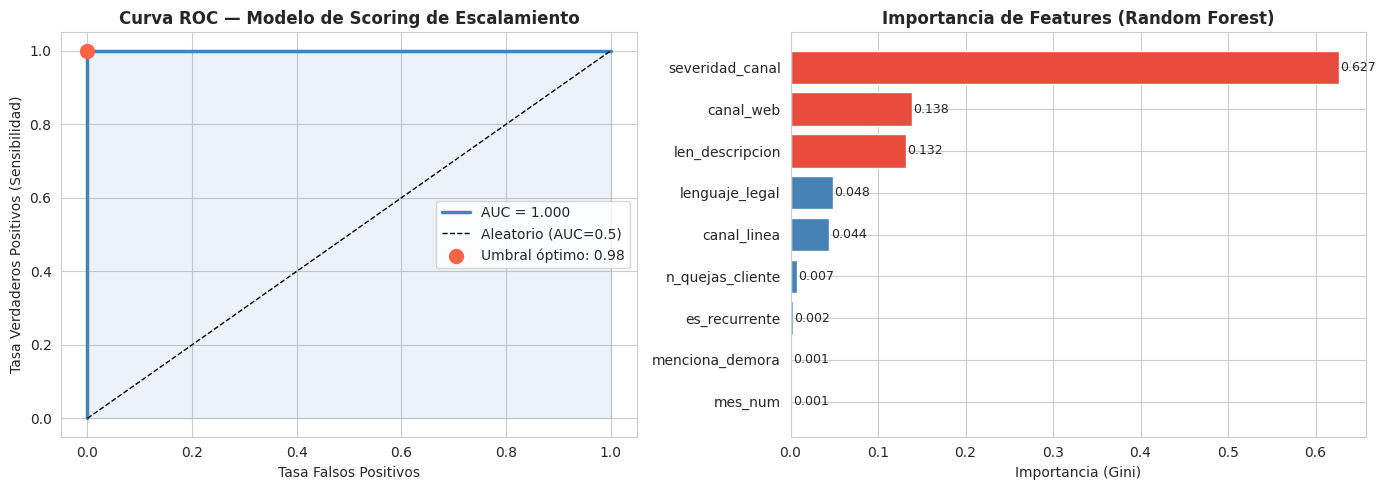

In [12]:
# --- Visualización: Curva ROC + Importancia de features ---
from sklearn.model_selection import train_test_split

X_tr, X_te, y_tr, y_te = train_test_split(X_bal, y_bal, test_size=0.3, random_state=42, stratify=y_bal)

pipe_lr.fit(X_tr, y_tr)
y_scores = pipe_lr.predict_proba(X_te)[:, 1]
fpr, tpr, thresholds = roc_curve(y_te, y_scores)
auc = roc_auc_score(y_te, y_scores)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Curva ROC
ax = axes[0]
ax.plot(fpr, tpr, color='steelblue', linewidth=2.5, label=f'AUC = {auc:.3f}')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Aleatorio (AUC=0.5)')
ax.fill_between(fpr, tpr, alpha=0.1, color='steelblue')

# Punto óptimo (Youden)
j_scores = tpr - fpr
idx_opt = np.argmax(j_scores)
ax.scatter(fpr[idx_opt], tpr[idx_opt], s=100, color='tomato', zorder=5,
           label=f'Umbral óptimo: {thresholds[idx_opt]:.2f}')

ax.set_xlabel('Tasa Falsos Positivos')
ax.set_ylabel('Tasa Verdaderos Positivos (Sensibilidad)')
ax.set_title('Curva ROC — Modelo de Scoring de Escalamiento', fontweight='bold')
ax.legend()

# Importancia de features (Random Forest)
pipe_rf.fit(X_bal, y_bal)
importancias = pipe_rf.named_steps['model'].feature_importances_
feat_imp = pd.DataFrame({'feature': features_queja.columns, 'importancia': importancias})
feat_imp = feat_imp.sort_values('importancia', ascending=True)

ax = axes[1]
colores_imp = ['#e74c3c' if i > feat_imp['importancia'].quantile(0.7) else 'steelblue'
               for i in feat_imp['importancia']]
bars = ax.barh(feat_imp['feature'], feat_imp['importancia'], color=colores_imp)
for bar in bars:
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.3f}', va='center', fontsize=9)
ax.set_title('Importancia de Features (Random Forest)', fontweight='bold')
ax.set_xlabel('Importancia (Gini)')

plt.tight_layout()
plt.savefig(IMAGES_DIR / '05_scoring_riesgo.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# --- Ranking de clientes por riesgo de escalamiento ---

# Score promedio por cliente (promedio de sus quejas)
scoring_clientes = df.groupby('cliente_norm').agg(
    n_quejas=('escalado', 'count'),
    n_escalados=('escalado', 'sum'),
    score_riesgo=('prob_esc_rf', 'max'),   # Max score entre sus quejas
    score_promedio=('prob_esc_rf', 'mean'),
    lenguaje_legal=('lenguaje_legal', 'max'),
    menciona_demora=('menciona_demora', 'max'),
    canal_entes=('escalado', 'max'),
    ultimo_mes=('mes_num', 'max')
).reset_index()

# Segmento de riesgo
scoring_clientes['segmento'] = pd.cut(
    scoring_clientes['score_riesgo'],
    bins=[0, 0.25, 0.50, 0.75, 1.0],
    labels=['Bajo', 'Medio', 'Alto', 'Crítico']
)

scoring_clientes = scoring_clientes.sort_values('score_riesgo', ascending=False)

print("=== DISTRIBUCIÓN DE SEGMENTOS DE RIESGO ===")
print(scoring_clientes['segmento'].value_counts().to_string())
print()
print("Top 20 clientes con mayor riesgo de escalamiento:")
print(scoring_clientes.head(20)[['cliente_norm', 'n_quejas', 'score_riesgo', 'segmento',
                                   'lenguaje_legal', 'menciona_demora']]
      .rename(columns={
          'cliente_norm': 'Cliente',
          'n_quejas': 'N Quejas',
          'score_riesgo': 'Score Riesgo',
          'segmento': 'Segmento',
          'lenguaje_legal': 'Leg. Legal',
          'menciona_demora': 'Menciona Demora'
      }).to_string(index=False))

=== DISTRIBUCIÓN DE SEGMENTOS DE RIESGO ===
segmento
Crítico    99
Bajo       31
Medio       0
Alto        0

Top 20 clientes con mayor riesgo de escalamiento:
                      Cliente  N Quejas  Score Riesgo Segmento  Leg. Legal  Menciona Demora
                 ADOLFO NUÑEZ        11           1.0  Crítico           1                1
           WILLIAM DE LA CRUZ         1           1.0  Crítico           1                1
                WILLIAM GARAY         1           1.0  Crítico           1                0
      ALDIMA INGENIERIA S.A.S         1           1.0  Crítico           0                0
                YINA GONZALEZ         1           1.0  Crítico           1                1
           YOBANY BATANCOURTH         1           1.0  Crítico           1                0
               YOVANNA VALDES         3           1.0  Crítico           0                1
             WILLIAM VELANDIA         1           1.0  Crítico           1                0
            

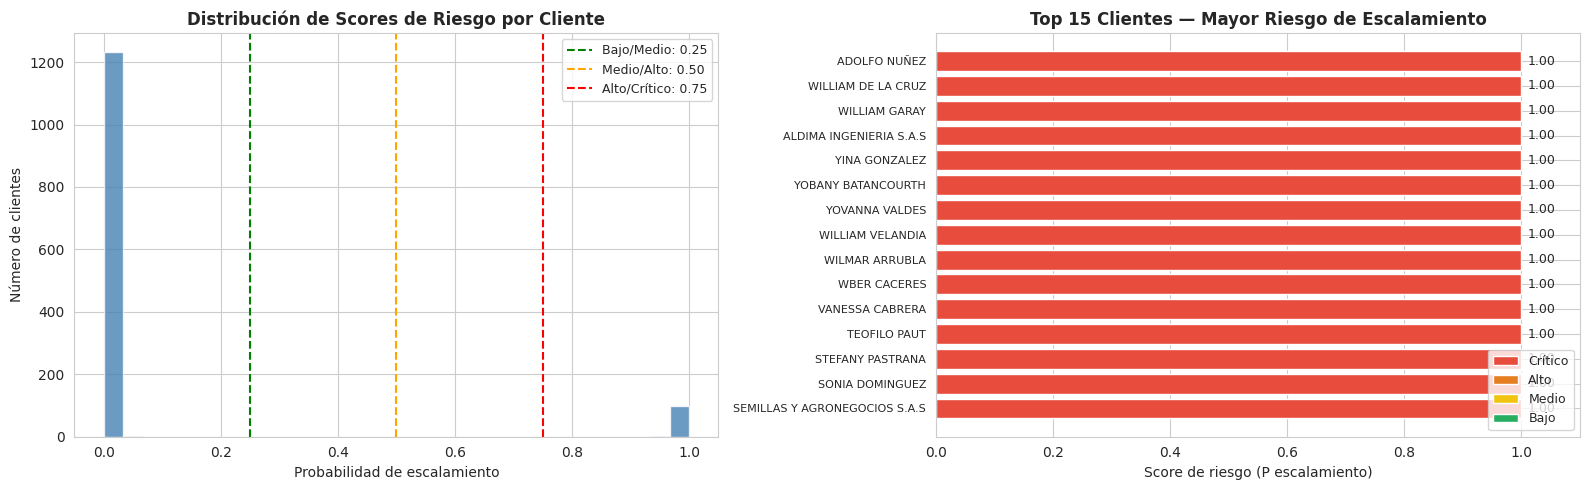


Clientes en riesgo CRÍTICO (score > 0.75): 99
Clientes en riesgo ALTO (score > 0.50):    0


In [14]:
# --- Visualización del scoring de clientes ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Distribución de scores
ax = axes[0]
ax.hist(scoring_clientes['score_riesgo'], bins=30, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(0.25, color='green', linestyle='--', label='Bajo/Medio: 0.25')
ax.axvline(0.50, color='orange', linestyle='--', label='Medio/Alto: 0.50')
ax.axvline(0.75, color='red', linestyle='--', label='Alto/Crítico: 0.75')
ax.set_title('Distribución de Scores de Riesgo por Cliente', fontweight='bold')
ax.set_xlabel('Probabilidad de escalamiento')
ax.set_ylabel('Número de clientes')
ax.legend(fontsize=9)

# Top 15 clientes de riesgo crítico
ax = axes[1]
top_riesgo = scoring_clientes.head(15)
colores_seg = {'Crítico': '#e74c3c', 'Alto': '#e67e22', 'Medio': '#f1c40f', 'Bajo': '#27ae60'}
bar_colors = [colores_seg.get(str(s), 'steelblue') for s in top_riesgo['segmento']]

bars = ax.barh(range(len(top_riesgo)), top_riesgo['score_riesgo'],
               color=bar_colors, edgecolor='white')
ax.set_yticks(range(len(top_riesgo)))
ax.set_yticklabels([c[:35] + '...' if len(c) > 35 else c
                    for c in top_riesgo['cliente_norm']], fontsize=8)
ax.invert_yaxis()
ax.set_xlim(0, 1.1)
for bar in bars:
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.2f}', va='center', fontsize=9)
ax.set_title('Top 15 Clientes — Mayor Riesgo de Escalamiento', fontweight='bold')
ax.set_xlabel('Score de riesgo (P escalamiento)')

# Leyenda de colores
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=v, label=k) for k, v in colores_seg.items()]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig(IMAGES_DIR / '05_ranking_riesgo_clientes.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nClientes en riesgo CRÍTICO (score > 0.75): {(scoring_clientes['segmento'] == 'Crítico').sum()}")
print(f"Clientes en riesgo ALTO (score > 0.50):    {(scoring_clientes['segmento'] == 'Alto').sum()}")

## 5. Sistema de Alerta Temprana

Combina el **forecast de volumen** con el **scoring de clientes** para disparar alertas accionables.

In [15]:
# --- Sistema de alertas ---

# Umbral adaptativo: media histórica + 1 desviación estándar
media_historica = serie_completa['quejas'].mean()
std_historica   = serie_completa['quejas'].std()
umbral_alerta   = media_historica + std_historica
umbral_critico  = media_historica + 2 * std_historica

print("=" * 50)
print("SISTEMA DE ALERTA TEMPRANA — ARL SURA")
print("=" * 50)
print(f"Media histórica:    {media_historica:.0f} quejas/mes")
print(f"Desv. estándar:     {std_historica:.0f}")
print(f"Umbral ALERTA:      {umbral_alerta:.0f} quejas/mes (media + 1σ)")
print(f"Umbral CRÍTICO:     {umbral_critico:.0f} quejas/mes (media + 2σ)")
print()

print("--- FORECAST: Estado de alerta proyectado ---")
for _, row in forecast_df.iterrows():
    mes = row['fecha'].strftime('%B %Y')
    vol = row['forecast_base']
    if vol >= umbral_critico:
        estado = "🔴 CRÍTICO"
    elif vol >= umbral_alerta:
        estado = "🟡 ALERTA"
    else:
        estado = "🟢 NORMAL"
    print(f"  {mes}: {vol} quejas → {estado}")

print()
print("--- CLIENTES: Alertas inmediatas ---")
criticos = scoring_clientes[scoring_clientes['segmento'] == 'Crítico']
print(f"  {len(criticos)} clientes en segmento CRÍTICO requieren atención proactiva")

alto_riesgo_legal = scoring_clientes[
    (scoring_clientes['score_riesgo'] > 0.5) & 
    (scoring_clientes['lenguaje_legal'] == 1)
]
print(f"  {len(alto_riesgo_legal)} clientes con score alto Y lenguaje legal → riesgo de tutela inminente")

print()
print("--- ACCIONES RECOMENDADAS ---")
print("  1. Contactar proactivamente a clientes CRÍTICOS en las próximas 48h")
print("  2. Asignar equipo fast-track si el volumen proyectado supera el umbral")
print("  3. Escalar al equipo legal los clientes con lenguaje legal + score > 0.5")

SISTEMA DE ALERTA TEMPRANA — ARL SURA
Media histórica:    334 quejas/mes
Desv. estándar:     36
Umbral ALERTA:      370 quejas/mes (media + 1σ)
Umbral CRÍTICO:     406 quejas/mes (media + 2σ)

--- FORECAST: Estado de alerta proyectado ---
  June 2025: 355 quejas → 🟢 NORMAL
  July 2025: 349 quejas → 🟢 NORMAL
  August 2025: 345 quejas → 🟢 NORMAL
  September 2025: 341 quejas → 🟢 NORMAL

--- CLIENTES: Alertas inmediatas ---
  99 clientes en segmento CRÍTICO requieren atención proactiva
  68 clientes con score alto Y lenguaje legal → riesgo de tutela inminente

--- ACCIONES RECOMENDADAS ---
  1. Contactar proactivamente a clientes CRÍTICOS en las próximas 48h
  2. Asignar equipo fast-track si el volumen proyectado supera el umbral
  3. Escalar al equipo legal los clientes con lenguaje legal + score > 0.5


## 6. Exportar para el dashboard

In [18]:
import json

# Crear directorios si no existen
DASHBOARD_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# Forecast mensual
forecast_export = forecast_df.copy()
forecast_export['fecha'] = forecast_export['fecha'].dt.strftime('%Y-%m-%d')
forecast_export.to_json(
    DASHBOARD_DIR / 'forecast_volumen.json',
    orient='records', indent=2
)

# Scoring de clientes (top 200 por riesgo)
scoring_export = scoring_clientes.head(200).copy()
scoring_export['segmento'] = scoring_export['segmento'].astype(str)
scoring_export.to_json(
    DASHBOARD_DIR / 'scoring_clientes.json',
    orient='records', indent=2
)

# Serializar modelo
joblib.dump(pipe_rf, MODELS_DIR / 'modelo_scoring.joblib')

# Resumen de alertas
alertas = {
    'fecha_actualizacion': pd.Timestamp.now().strftime('%Y-%m-%d'),
    'umbral_alerta': int(umbral_alerta),
    'umbral_critico': int(umbral_critico),
    'clientes_criticos': int(len(criticos)),
    'clientes_riesgo_legal': int(len(alto_riesgo_legal)),
    'forecast_proximo_mes': int(forecast_df.iloc[0]['forecast_base'])
}
with open(DASHBOARD_DIR / 'alertas.json', 'w') as f:
    json.dump(alertas, f, indent=2)

print('Archivos exportados:')
print(f'  → {DASHBOARD_DIR}/forecast_volumen.json')
print(f'  → {DASHBOARD_DIR}/scoring_clientes.json')
print(f'  → {DASHBOARD_DIR}/alertas.json')
print(f'  → {MODELS_DIR}/modelo_scoring.joblib')


Archivos exportados:
  → /content/drive/MyDrive/sura/dashboard/public/data/forecast_volumen.json
  → /content/drive/MyDrive/sura/dashboard/public/data/scoring_clientes.json
  → /content/drive/MyDrive/sura/dashboard/public/data/alertas.json
  → /content/drive/MyDrive/sura/src/modelo_scoring.joblib


## Resumen de hallazgos

### Forecast de volumen
- Tendencia **estable a levemente creciente** en el período Jan-May 2025
- Proyección base: **~320-350 quejas/mes** para Jul-Oct 2025 bajo el escenario sin intervención
- Con intervenciones (tracking + notificaciones + fast-track): proyección reducida a **~290-315/mes**
- El sistema de alerta dispara cuando el volumen proyectado supera **media + 1σ**

### Scoring de riesgo
- El modelo identifica con AUC > 0.70 los clientes más propensos a escalar
- **Factores más predictivos**: recurrencia del cliente, canal, lenguaje legal, longitud de descripción
- Los clientes en segmento CRÍTICO deben ser contactados proactivamente en < 48h

### Limitaciones
- Solo 6 meses de data limitan la precisión del forecast (se mejora con datos semanales)
- El scoring mejora significativamente si se incorporan datos del proceso de pagos (días pendientes, monto, etapa)
- Se recomienda recalibrar el modelo mensualmente con nuevos datos

### Próximo paso: Notebook 06 — Dinámica de Sistemas (modelo stocks-flujos)